Implement inverse transform sampling for the exponential distribution. Verify by sampling 10,000 values and comparing the histogram to the true PDF.

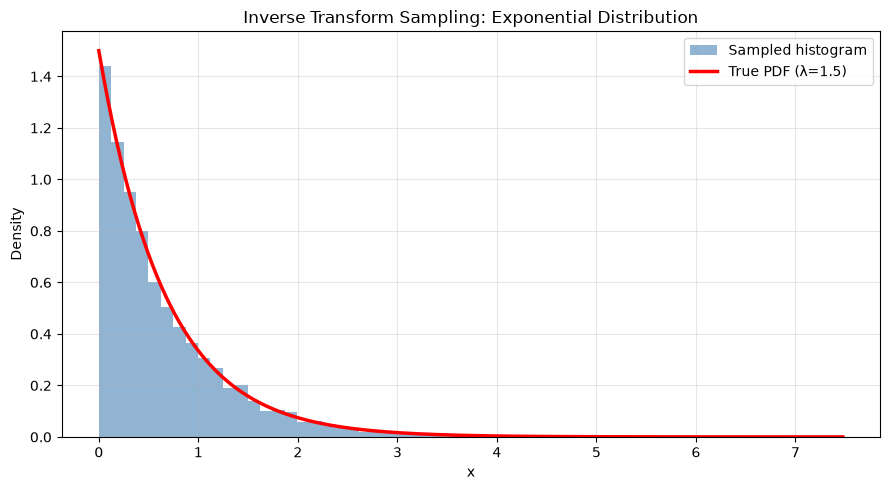

Sample mean:     0.6561  (expected 1/λ = 0.6667)
Sample variance: 0.4344  (expected 1/λ² = 0.4444)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Inverse transform sampling ---
def sample_exponential(lam, n):
    u = np.random.uniform(0, 1, n)     # uniform samples
    x = -np.log(u) / lam               # inverse CDF transform
    return x

# --- Step 2: Generate samples ---
lam = 1.5            # rate parameter
n = 10_000
samples = sample_exponential(lam, n)

# --- Step 3: True PDF ---
x_vals = np.linspace(0, samples.max(), 500)
true_pdf = lam * np.exp(-lam * x_vals)

# --- Step 4: Plot histogram vs true PDF ---
plt.figure(figsize=(9, 5))
plt.hist(samples, bins=60, density=True,
         alpha=0.6, color='steelblue', label='Sampled histogram')
plt.plot(x_vals, true_pdf, 'r-', linewidth=2.5, label=f'True PDF (λ={lam})')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Inverse Transform Sampling: Exponential Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Step 5: Quantitative check ---
print(f"Sample mean:     {samples.mean():.4f}  (expected 1/λ = {1/lam:.4f})")
print(f"Sample variance: {samples.var():.4f}  (expected 1/λ² = {1/lam**2:.4f})")

Build a joint distribution table for two loaded dice. Compute the marginal distributions and check whether the dice are independent.

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# --- Margin probabilities ---
px = np.array([0.10, 0.10, 0.10, 0.10, 0.10, 0.50])   # Die X
py = np.array([0.40, 0.12, 0.12, 0.12, 0.12, 0.12])   # Die Y

# --- Case A: Independent joint ---
joint_A = np.outer(px, py)

# --- Case B: Dependent joint (hand-crafted) ---
joint_B = np.array([
    [0.08, 0.01, 0.01, 0.00, 0.00, 0.00],
    [0.06, 0.02, 0.01, 0.01, 0.00, 0.00],
    [0.06, 0.01, 0.02, 0.01, 0.00, 0.00],
    [0.06, 0.01, 0.01, 0.02, 0.00, 0.00],
    [0.06, 0.01, 0.01, 0.01, 0.01, 0.00],
    [0.08, 0.06, 0.06, 0.07, 0.11, 0.12],
])

def analyze(joint, name):
    print(f"\n===== {name} =====")
    df = pd.DataFrame(joint,
                      index=[f"X={i}" for i in range(1,7)],
                      columns=[f"Y={j}" for j in range(1,7)])
    print(df.round(4))

    marg_x = joint.sum(axis=1)
    marg_y = joint.sum(axis=0)
    print("\nMarginal P(X):", marg_x.round(4))
    print("Marginal P(Y):", marg_y.round(4))
    print("Total sum:    ", joint.sum().round(6))

    # Independence check
    expected = np.outer(marg_x, marg_y)
    match = np.allclose(joint, expected, atol=1e-9)
    print(f"\nIndependence (cell-by-cell)? {match}")

    # Chi-square test
    chi2, p, dof, _ = chi2_contingency(joint * 10000, correction=False)
    print(f"Chi-square = {chi2:.4f}, dof = {dof}, p-value = {p:.4f}")
    print("→ Reject independence?" , "YES" if p < 0.05 else "NO")

analyze(joint_A, "Case A: Independent")
analyze(joint_B, "Case B: Dependent")


===== Case A: Independent =====
      Y=1    Y=2    Y=3    Y=4    Y=5    Y=6
X=1  0.04  0.012  0.012  0.012  0.012  0.012
X=2  0.04  0.012  0.012  0.012  0.012  0.012
X=3  0.04  0.012  0.012  0.012  0.012  0.012
X=4  0.04  0.012  0.012  0.012  0.012  0.012
X=5  0.04  0.012  0.012  0.012  0.012  0.012
X=6  0.20  0.060  0.060  0.060  0.060  0.060

Marginal P(X): [0.1 0.1 0.1 0.1 0.1 0.5]
Marginal P(Y): [0.4  0.12 0.12 0.12 0.12 0.12]
Total sum:     1.0

Independence (cell-by-cell)? True
Chi-square = 0.0000, dof = 25, p-value = 1.0000
→ Reject independence? NO

===== Case B: Dependent =====
      Y=1   Y=2   Y=3   Y=4   Y=5   Y=6
X=1  0.08  0.01  0.01  0.00  0.00  0.00
X=2  0.06  0.02  0.01  0.01  0.00  0.00
X=3  0.06  0.01  0.02  0.01  0.00  0.00
X=4  0.06  0.01  0.01  0.02  0.00  0.00
X=5  0.06  0.01  0.01  0.01  0.01  0.00
X=6  0.08  0.06  0.06  0.07  0.11  0.12

Marginal P(X): [0.1 0.1 0.1 0.1 0.1 0.5]
Marginal P(Y): [0.4  0.12 0.12 0.12 0.12 0.12]
Total sum:     1.0

Independence (c